In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Period & Domain

In [2]:
iyear=1981
fyear=2015
dom='HMA'
latS,latN,lonW,lonE,latlim,lonlim = coord_domain('HMA')

# Precipitation datas loading

In [3]:
#####################  APHRO  #####################################

model1='aphro'
res1=str('0.25°x0.25°')
ds1 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/aphro/monthly/APHRO_mon_MA_025deg_V1101_EXR1.1951-2015.nc'
                      ,decode_times=False)['precip']
start_date = pd.Timestamp('1951-01-01')
# Create new time index
nmonths = ds1.time.size
time_new = pd.date_range(start=start_date, periods=nmonths, freq='MS')  # 'MS' = Month Start
# Replace time in dataset
ds1['time'] = time_new
ds1=reversing_lat(ds1)
ds1=ds1.rename({'latitude':'lat','longitude':'lon'})
field1_mm_day=field_dom(ds1,dom)
field1_mm_day=field1_mm_day.sel(time=slice(str(iyear),str(fyear)))

# Convert mm/day to mm/month
days_in_month = field1_mm_day['time'].dt.days_in_month
field1= field1_mm_day * days_in_month


In [4]:
ds1_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_aphro.nc')['elevation']
ds1_SH=ds1_SH_raw.rename({'latitude':'lat','longitude':'lon'})
ds1_SH=reversing_lat(ds1_SH)
field1_SH=field_dom(ds1_SH,dom)

In [5]:
#####################  GPCP  #####################################

model2='gpcp'
res2=str('1.0°x1.0°')
ds2= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gpcp/precip_mon.gpcp_v2020_1891_2019_10.nc')['precip']

field2=field_dom(ds2,dom)
field2=field2.sel(time=slice(str(iyear),str(fyear)))

In [23]:
field2

<xarray.DataArray 'precip' (time: 420, lat: 25, lon: 50)> Size: 2MB
[525000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2015-12-01
  * lon      (lon) float64 400B 60.5 61.5 62.5 63.5 ... 106.5 107.5 108.5 109.5
  * lat      (lat) float64 200B 44.5 43.5 42.5 41.5 40.5 ... 23.5 22.5 21.5 20.5
Attributes:
    long_name:    gpcc full data monthly product version 2020, precipitation ...
    units:        mm/month
    code:         20
    institution:  DWD

In [6]:
ds2_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_gpcp.nc')['elevation']
field2_SH=field_dom(ds2_SH,dom)

In [7]:
#####################  CRU  #####################################

model3='cru'
res3=str('0.5°x0.5°')

ds3_raw= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/cru/cru_ts4.05.1901.2020.pre.dat.nc')['pre']
ds3=reversing_lat(ds3_raw)
field3=field_dom(ds3,dom)
field3=field3.sel(time=slice(str(iyear),str(fyear)))


In [8]:
ds3_SH_raw=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_cru_hma_grid.nc')['elevation']
ds3_SH=reversing_lat(ds3_SH_raw)
field3_SH=field_dom(ds3_SH,dom)

In [9]:
#####################  CHIRPS  #####################################

model4='chirps'
res4='0.05°x0.05°'

ds4 = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/chirps/chirps-v2.0.monthly.nc')['precip']
ds4=ds4.rename({'latitude':'lat','longitude':'lon'})
ds4=reversing_lat(ds4)
field4=field_dom(ds4,dom)
field4=field4.sel(time=slice(str(iyear),str(fyear)))


In [24]:
field4

<xarray.DataArray 'precip' (time: 420, lat: 500, lon: 1000)> Size: 840MB
[210000000 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 2kB 44.97 44.92 44.87 44.82 ... 20.12 20.07 20.02
  * lon      (lon) float32 4kB 60.02 60.07 60.12 60.18 ... 109.9 109.9 110.0
  * time     (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2015-12-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0

In [10]:
ds4_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/'+'gmted_on_chirps_hma_grid.nc')['elevation']
ds4_SH=ds4_SH.rename({'latitude':'lat','longitude':'lon'})
ds4_SH=reversing_lat(ds4_SH)
field4_SH=field_dom(ds4_SH,dom)

In [11]:
#####################  HARv2  #####################################

model5='HARv2'
res5='10kmx10km'

ds5_raw0= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_mon_d10km_d_2d_prcp_1980-2023.nc')['prcp']
ds5_raw=ds5_raw0*24 #mm/h
# Calculate days in each month
days_in_month5= ds5_raw['time'].dt.days_in_month
# Convert to mm/month
ds5= ds5_raw* days_in_month5

def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE,latlim,lonlim=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# Apply mask (non-NaN where the condition is True)
field5=xy_sel_dom(ds5.sel(time=slice(str(iyear),str(fyear))),latS,latN,lonW,lonE)

time
lon
lat
west_east
south_north


In [12]:
ds5_grM= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/HARv2_d10km_static_hgt.nc')
ds5_SH=ds5_grM['hgt'][0,:,:]
field5_SH=xy_sel_dom(ds5_SH,latS,latN,lonW,lonE)

time
west_east
south_north
lon
lat


In [13]:
#####################  ERA5  #####################################

model6='era5'
res6=str('0.25°x0.25°')

ds6_raw= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/era5/'
                         +'tp.mon_era5_1940-2025_NH_025x025.nc')['tp']
ds6=ds6_raw.rename({'valid_time': 'time','latitude':'lat','longitude':'lon'})
ds6=ds6.sel(time=slice(str(iyear),str(fyear)))

field6_m_day=field_dom(ds6,dom)

# Convert m/day to mm/month
days_in_month = field6_m_day['time'].dt.days_in_month
field6= field6_m_day * days_in_month * 1000



In [14]:
ds6_SH=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
ds6_SH=ds6_SH.rename({'latitude':'lat','longitude':'lon'})
field6_SH=field_dom(ds6_SH,dom)

# Annual Climatology

In [15]:
models = ['APHRO','GPCP','CRU','CHIRPS','HARv2','ERA5']

In [22]:
tp_mean1 = field1.mean(dim='time', skipna=True)

In [23]:
tp_mean2 = field2.mean(dim='time', skipna=True)

In [24]:
tp_mean3 = field3.mean(dim='time', skipna=True)

In [28]:
field4 = field4.chunk({"time": 12})
tp_mean4 = field4.mean(dim='time', skipna=True)
tp_mean4 = tp_mean4.compute()

In [26]:
tp_mean5 = field5.mean(dim='time', skipna=True)

In [27]:
tp_mean6 = field6.mean(dim='time', skipna=True)

In [29]:
tp_mean_dict = {
    models[0]: tp_mean1,
    models[1]: tp_mean2,
    models[2]: tp_mean3,
    models[3]: tp_mean4,
    models[4]: tp_mean5,
    models[5]: tp_mean6}

In [16]:
field_SH_dict = {
    models[0]: field1_SH,
    models[1]: field2_SH,
    models[2]: field3_SH,
    models[3]: field4_SH,
    models[4]: field5_SH,
    models[5]: field6_SH}

500


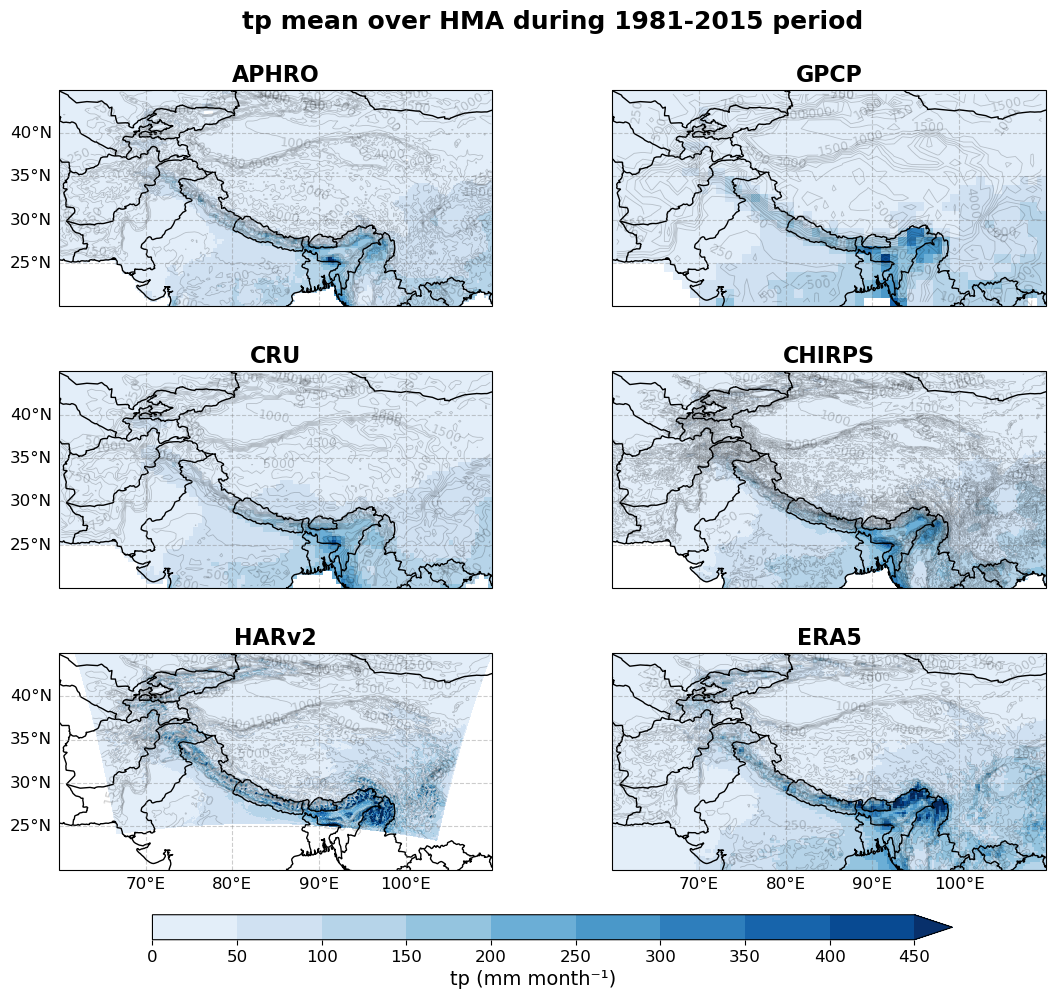

In [31]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
cmap = plt.get_cmap("Blues", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_mean_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Seasonal Climatology

# DJFM

In [32]:
tp_season_dict = {}
season = 'DJFM'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

250


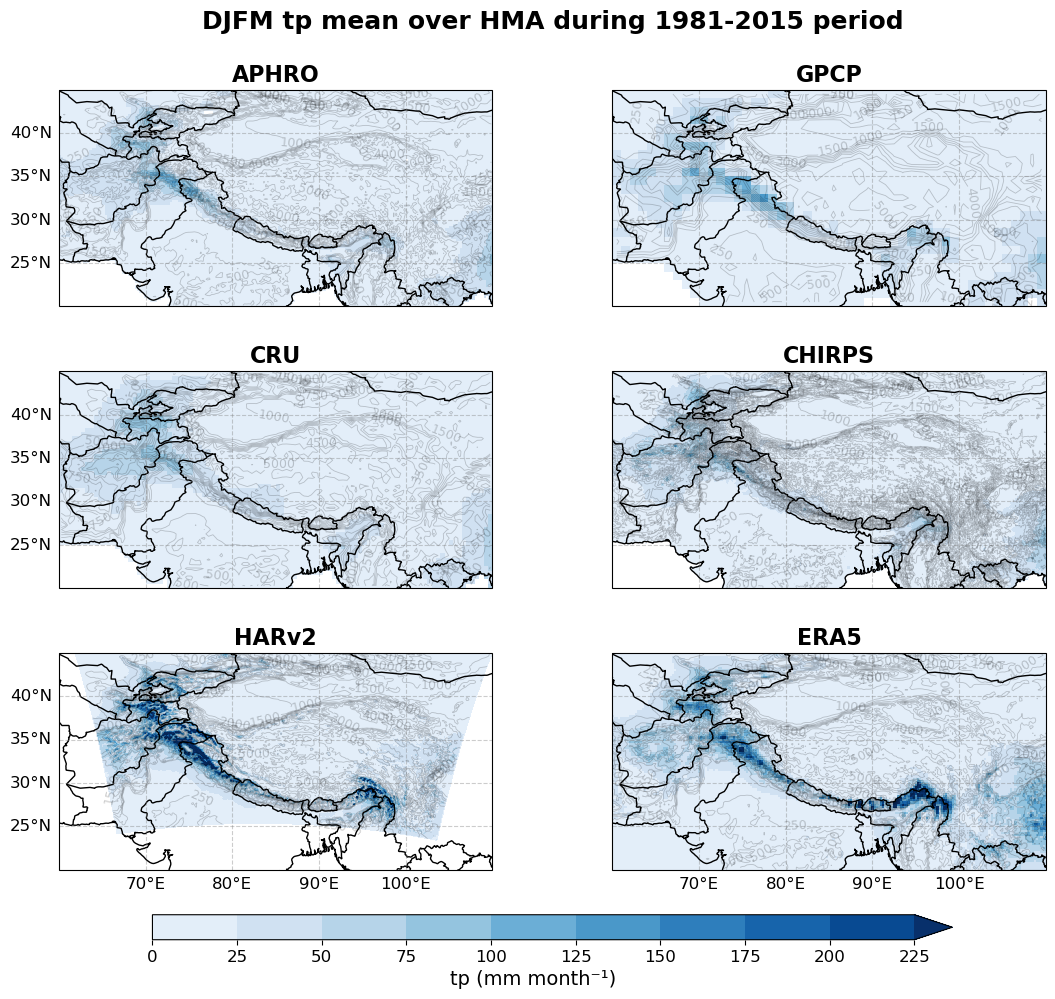

In [33]:
vmax = 250
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
cmap = plt.get_cmap("Blues", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season} tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# AM

In [34]:
tp_season_dict = {}
season = 'AM'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

500


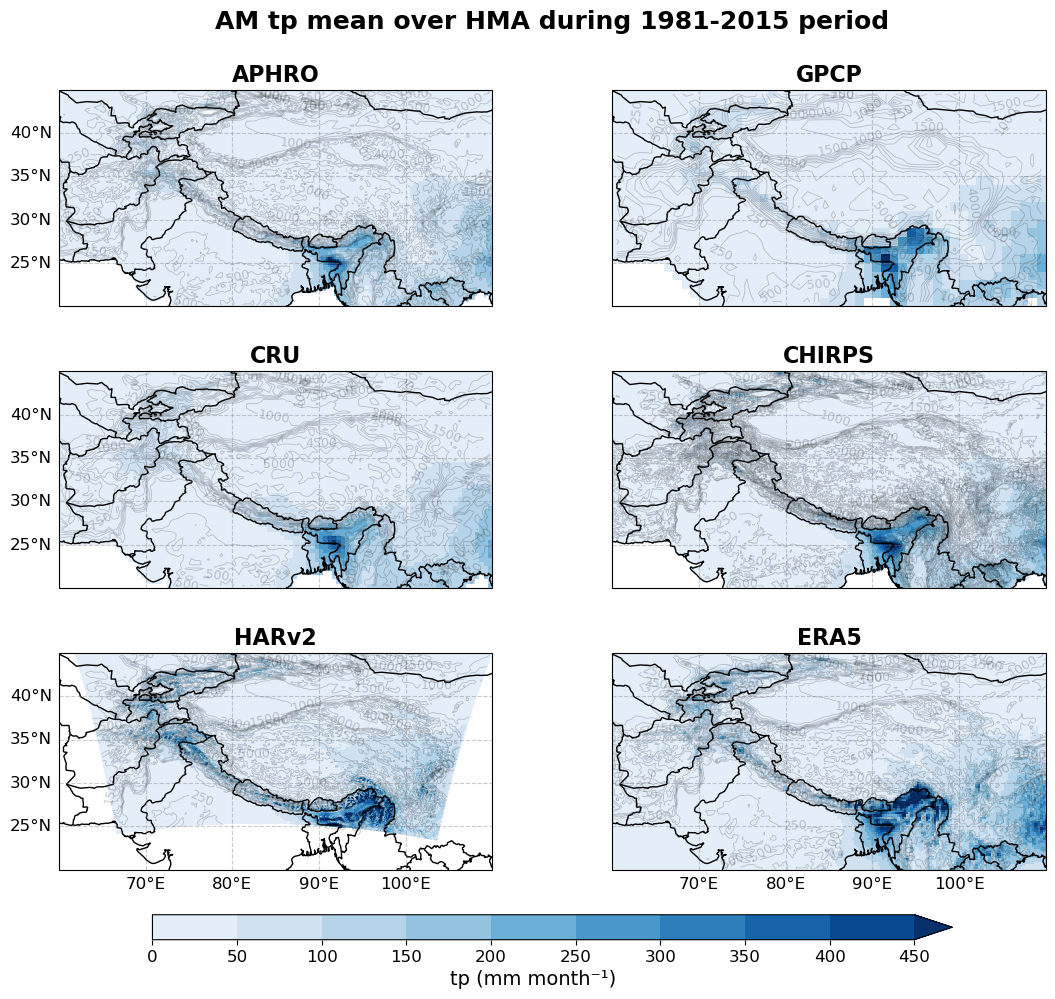

In [35]:
vmax = 500
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 50)
cmap = plt.get_cmap("Blues", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season} tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# JJAS

In [36]:
tp_season_dict = {}
season = 'JJAS'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

900


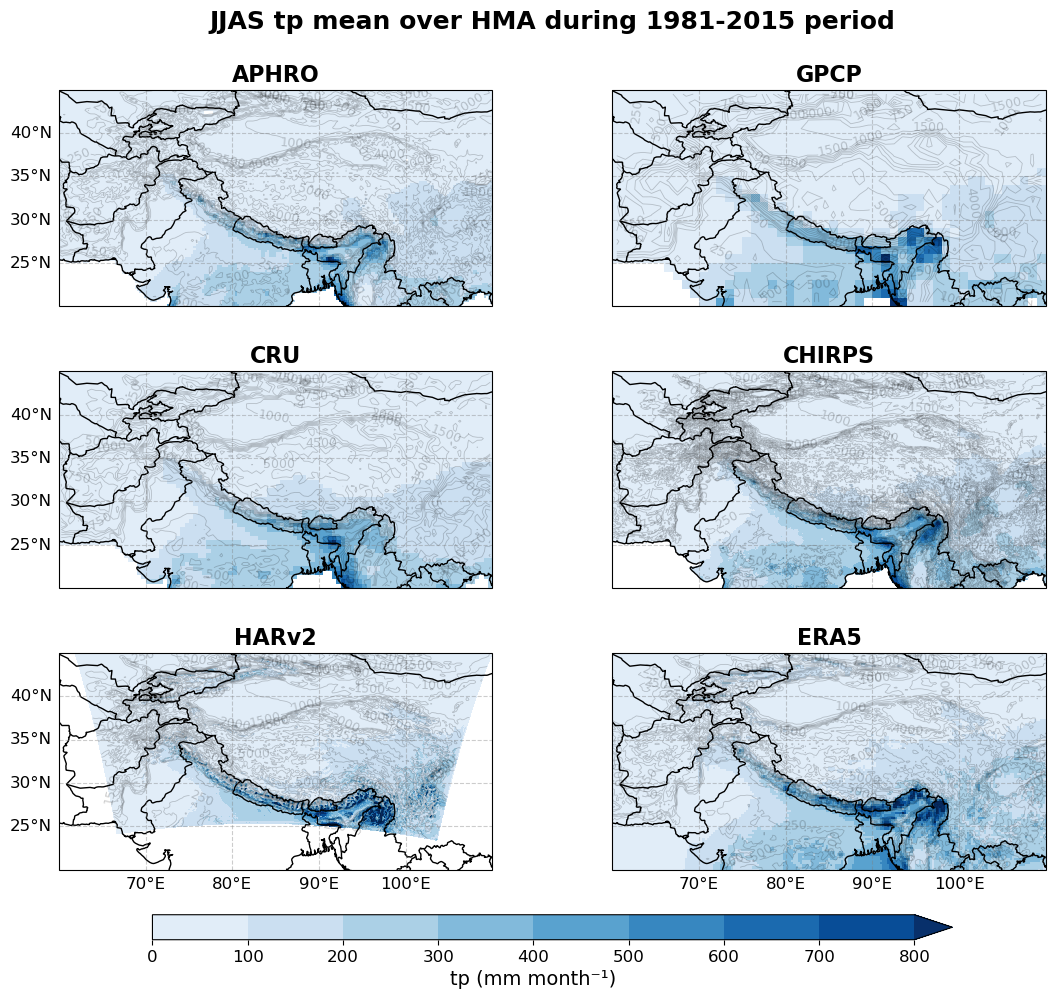

In [37]:
vmax = 900
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 100)
cmap = plt.get_cmap("Blues", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season} tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# ON

In [38]:
tp_season_dict = {}
season = 'ON'

tp_season1 = clim(field1, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[0]] = tp_season1

tp_season2 = clim(field2, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[1]] = tp_season2

tp_season3 = clim(field3, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[2]] = tp_season3

tp_season4 = clim(field4, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[3]] = tp_season4

tp_season5 = clim(field5, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[4]] = tp_season5

tp_season6 = clim(field6, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
tp_season_dict[models[5]] = tp_season6

250


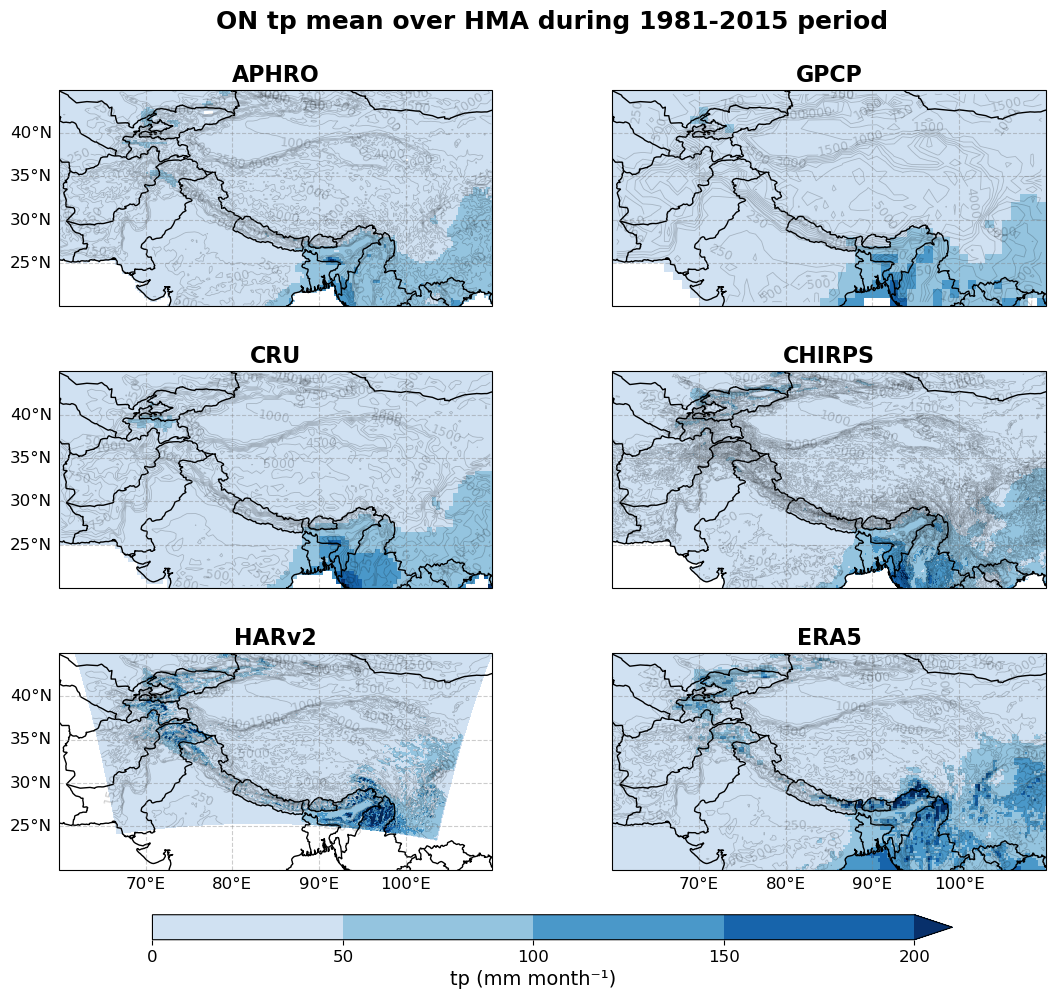

In [39]:
vmax = 250
#vmax = max(np.ceil(float(np.nanmax(np.abs(ds)))) for ds in tp_mean_dict.values())
print(vmax)
levels = np.arange(0, vmax, 25)
cmap = plt.get_cmap("Blues", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = tp_season_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm month⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"{season} tp mean over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

# Annual Trend

In [17]:
trend_annual_dict={}
p_annual_dict={}
season='annual'

In [18]:
tp_annual1,_ = seasonal_selection(field1, 'JFMAMJJASOND', iyear, fyear)
par1 = trend_vect(tp_annual1.time,tp_annual1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_annual_dict[models[0]] = trend1
p_annual_dict[models[0]] = p1

In [19]:
tp_annual2,_ = seasonal_selection(field2, 'JFMAMJJASOND', iyear, fyear)
par2 = trend_vect(tp_annual2.time,tp_annual2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_annual_dict[models[1]] = trend2
p_annual_dict[models[1]] = p2

In [20]:
tp_annual3,_ = seasonal_selection(field3, 'JFMAMJJASOND', iyear, fyear)
par3 = trend_vect(tp_annual3.time,tp_annual3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_annual_dict[models[2]] = trend1
p_annual_dict[models[2]] = p3

In [ ]:
#tp_annual4,_ = seasonal_selection(field4, season, iyear, fyear)
#par4 = trend_vect(tp_annual4.time,tp_annual4,dim='time')
#trend4 = par4[0];p4 = par4[3]
#trend_annual_dict[models[3]] = trend4
#p_annual_dict[models[3]] = p4

In [25]:
field4 = field4.chunk({"time": 12})

In [26]:
tp_annual4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)

In [27]:
tp_annual4=tp_annual4.compute()

In [28]:
par4 = trend_vect(tp_annual4.time,tp_annual4,dim='time')

In [30]:
trend4 = par4[0];p4 = par4[3]
trend_annual_dict[models[3]] = trend4
p_annual_dict[models[3]] = p4

In [21]:
tp_annual5,_ = seasonal_selection(field5, 'JFMAMJJASOND', iyear, fyear)
par5 = trend_vect(tp_annual5.time,tp_annual5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_annual_dict[models[4]] = trend5
p_annual_dict[models[4]] = p5

In [22]:
tp_annual6,_ = seasonal_selection(field6, 'JFMAMJJASOND', iyear, fyear)
par6 = trend_vect(tp_annual6.time,tp_annual6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_annual_dict[models[5]] = trend6
p_annual_dict[models[5]] = p6

In [ ]:
step_p = {
    models[0]: 4,
    models[1]: 1,
    models[2]: 4,
    models[3]: 20,
    models[4]: 6,
    models[5]: 3}

step = 0.5
vmax = 5
#vmax = max(np.round(float(np.nanmax(np.abs(ds))), 1) for ds in trend_annual_dict.values())
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

fig, axes = plt.subplots(3, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    model = models[i]
    data_model = trend_annual_dict[model]

    im = ax.pcolormesh(data_model['lon'],data_model['lat'],data_model,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    sig = p_annual_dict[model] < 0.05 
    step = step_p[model]
    lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][np.where(sig[::step, ::step])],lat_grid[::step, ::step][np.where(sig[::step, ::step])],
           color='black', s=2.5, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.7)
    
    ax.set_extent([lonW,lonE,latS,latN], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(field_SH_dict[model].lon,field_SH_dict[model].lat,field_SH_dict[model],levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.2,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(model, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 4) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (mm month⁻¹ / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.12, wspace=-0.3, hspace=0.3)
plt.suptitle(f"Annual tp trend over HMA during {iyear}-{fyear} period", fontsize=18, weight="bold")

plt.show()

5


# Seasonal Trend

# DJFM

In [ ]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='DJFM'

In [ ]:
tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_seasonal_dict[models[2]] = trend1
p_seasonal_dict[models[2]] = p3

tp_seasonal4,_ = seasonal_selection_chunk(field4, season, iyear, fyear)
par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')
trend4 = par4[0];p4 = par4[3]
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

tp_seasonal5,_ = seasonal_selection(field5, season, iyear, fyear)
par5 = trend_vect(tp_seasonal5.time,tp_seasonal5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

# AM

In [ ]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='AM'

In [ ]:
tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_seasonal_dict[models[2]] = trend1
p_seasonal_dict[models[2]] = p3

tp_seasonal4,_ = seasonal_selection(field4, season, iyear, fyear)
par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')
trend4 = par4[0];p4 = par4[3]
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

tp_seasonal5,_ = seasonal_selection(field5, season, iyear, fyear)
par5 = trend_vect(tp_seasonal5.time,tp_seasonal5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

# JJAS

In [ ]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='JJAS'

In [ ]:
tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_seasonal_dict[models[2]] = trend1
p_seasonal_dict[models[2]] = p3

tp_seasonal4,_ = seasonal_selection(field4, season, iyear, fyear)
par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')
trend4 = par4[0];p4 = par4[3]
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

tp_seasonal5,_ = seasonal_selection(field5, season, iyear, fyear)
par5 = trend_vect(tp_seasonal5.time,tp_seasonal5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6

# ON

In [ ]:
trend_seasonal_dict={}
p_seasonal_dict={}
season='ON'

In [ ]:
tp_seasonal1,_ = seasonal_selection(field1, season, iyear, fyear)
par1 = trend_vect(tp_seasonal1.time,tp_seasonal1,dim='time')
trend1 = par1[0];p1 = par1[3]
trend_seasonal_dict[models[0]] = trend1
p_seasonal_dict[models[0]] = p1

tp_seasonal2,_ = seasonal_selection(field2, season, iyear, fyear)
par2 = trend_vect(tp_seasonal2.time,tp_seasonal2,dim='time')
trend2 = par2[0];p2 = par2[3]
trend_seasonal_dict[models[1]] = trend2
p_seasonal_dict[models[1]] = p2

tp_seasonal3,_ = seasonal_selection(field3, season, iyear, fyear)
par3 = trend_vect(tp_seasonal3.time,tp_seasonal3,dim='time')
trend3 = par3[0];p3 = par3[3]
trend_seasonal_dict[models[2]] = trend1
p_seasonal_dict[models[2]] = p3

tp_seasonal4,_ = seasonal_selection(field4, season, iyear, fyear)
par4 = trend_vect(tp_seasonal4.time,tp_seasonal4,dim='time')
trend4 = par4[0];p4 = par4[3]
trend_seasonal_dict[models[3]] = trend4
p_seasonal_dict[models[3]] = p4

tp_seasonal5,_ = seasonal_selection(field5, season, iyear, fyear)
par5 = trend_vect(tp_seasonal5.time,tp_seasonal5,dim='time')
trend5 = par5[0];p5 = par5[3]
trend_seasonal_dict[models[4]] = trend5
p_seasonal_dict[models[4]] = p5

tp_seasonal6,_ = seasonal_selection(field6, season, iyear, fyear)
par6 = trend_vect(tp_seasonal6.time,tp_seasonal6,dim='time')
trend6 = par6[0];p6 = par6[3]
trend_seasonal_dict[models[5]] = trend6
p_seasonal_dict[models[5]] = p6